First 10 rows of the dataset:
   5.1  3.5  1.4  0.2  Setosa
0  4.9  3.0  1.4  0.2  Setosa
1  4.7  3.2  1.3  0.2  Setosa
2  4.6  3.1  1.5  0.2  Setosa
3  5.0  3.6  1.4  0.2  Setosa
4  5.4  3.9  1.7  0.4  Setosa
5  4.6  3.4  1.4  0.3  Setosa
6  5.0  3.4  1.5  0.2  Setosa
7  4.4  2.9  1.4  0.2  Setosa
8  4.9  3.1  1.5  0.1  Setosa
9  5.4  3.7  1.5  0.2  Setosa

Training data size: 7
Testing data size: 142

Confusion Matrix:
[[45  0  0]
 [ 0 48  1]
 [ 0 12 36]]

Accuracy:
0.9084507042253521

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        45
  Versicolor       0.80      0.98      0.88        49
   Virginica       0.97      0.75      0.85        48

    accuracy                           0.91       142
   macro avg       0.92      0.91      0.91       142
weighted avg       0.92      0.91      0.91       142


Confusion Matrix for RBF:
[[45  0  0]
 [ 8  0 41]
 [ 0  0 48]]

Accuracy for RBF:
0.6549295774647887


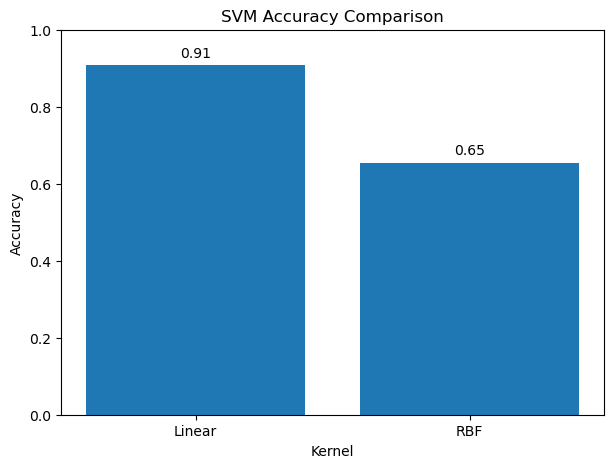

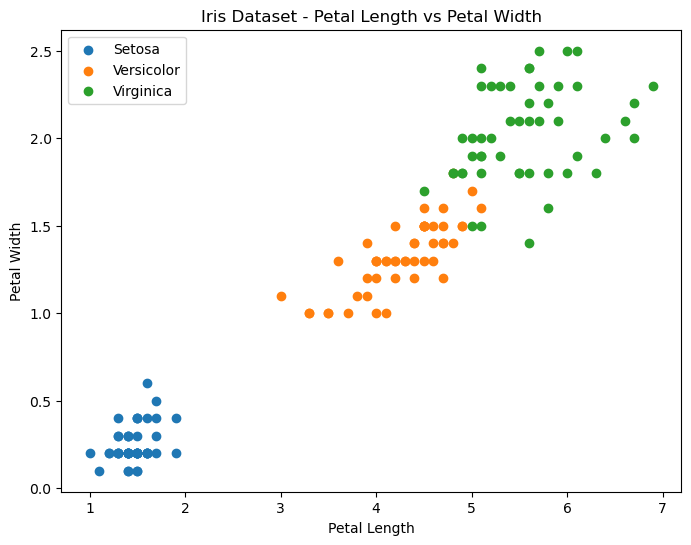

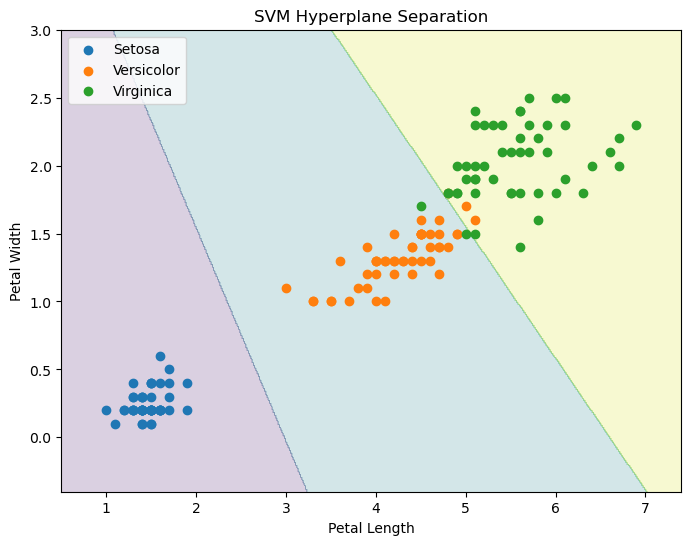

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("iris1.csv")

print("First 10 rows of the dataset:")
print(df.head(10))

array = df.values

X = array[:, 0:4]
y = array[:, 4]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.95, random_state=0
)

print("\nTraining data size:", len(X_train))
print("Testing data size:", len(X_test))

model = SVC(kernel='linear', random_state=0)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\nConfusion Matrix:")
conf = confusion_matrix(y_test, pred)
print(conf)

print("\nAccuracy:")
linear_accuracy = accuracy_score(y_test, pred)
print(linear_accuracy)

print("\nClassification Report:")
report = classification_report(y_test, pred)
print(report)

model1 = SVC(kernel='rbf', random_state=0)

model1.fit(X_train, y_train)

pred_rbf = model1.predict(X_test)

print("\nConfusion Matrix for RBF:")
conf_rbf = confusion_matrix(y_test, pred_rbf)
print(conf_rbf)

print("\nAccuracy for RBF:")
rbf_accuracy = accuracy_score(y_test, pred_rbf)
print(rbf_accuracy)

kernels = ['Linear', 'RBF']
accuracies = [linear_accuracy, rbf_accuracy]

plt.figure(figsize=(7, 5))

plt.bar(kernels, accuracies)

plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy Comparison")

plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.02, f"{value:.2f}", ha='center')

plt.show()

species_list = df.iloc[:, 4].unique()

plt.figure(figsize=(8, 6))

for species in species_list:
    data = df[df.iloc[:, 4] == species]

    plt.scatter(
        data.iloc[:, 2],
        data.iloc[:, 3],
        label=species
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset - Petal Length vs Petal Width")
plt.legend()

plt.show()

X_2D = df.iloc[:, [2, 3]].values
y_2D = df.iloc[:, 4].values

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y_2D)

svm_2d = SVC(kernel='linear')

svm_2d.fit(X_2D, y_encoded)

x_min = X_2D[:, 0].min() - 0.5
x_max = X_2D[:, 0].max() + 0.5

y_min = X_2D[:, 1].min() - 0.5
y_max = X_2D[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = svm_2d.predict(grid)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

for i, species in enumerate(species_list):
    data = df[df.iloc[:, 4] == species]

    plt.scatter(
        data.iloc[:, 2],
        data.iloc[:, 3],
        label=species
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("SVM Hyperplane Separation")
plt.legend()

plt.show()